In [1]:
import jax
import jax.numpy as jnp
import numpy as np

import pyproj
import matplotlib.pyplot as plt
plt.rcParams["font.size"] = 20

import optax
from OkadaJAX import OkadaWrapper
okada = OkadaWrapper()

In [2]:
import os
os.environ['CUDA_VISIBLE_DEVICES'] = '1'
# os.makedirs("figs_loss", exist_ok=True)

# Generate observation data (synthetic data + some noise)

In [3]:
# domain
lon_min, lon_max = 142, 148
lat_min, lat_max = 37, 43
dlon, dlat = 0.25, 0.25 # very sparse
nlon, nlat = int((lon_max-lon_min)/dlon)+1, int((lat_max-lat_min)/dlon)+1
lon_mid, lat_mid = (lon_min+lon_max)/2, (lat_min+lat_max)/2


# coordinate transformation
ll2xy = pyproj.Transformer.from_crs(
    crs_from="EPSG:4326", # WGS84
    crs_to=f"+proj=tmerc +lon_0={lon_mid} +lat_0={lat_mid} +ellps=WGS84 +datum=WGS84 +units=km", 
    always_xy=True
)

lon = jnp.linspace(lon_min, lon_max, nlon)
lat = jnp.linspace(lat_min, lat_max, nlat)
Lon, Lat = jnp.meshgrid(lon, lat)
X_obs, Y_obs = ll2xy.transform(Lon, Lat)

X_min, X_max = X_obs.min(), X_obs.max()
Y_min, Y_max = Y_obs.min(), Y_obs.max()
dX, dY = (X_max - X_min) / 2, (Y_max - Y_min) / 2
print(dX, dY)


coords = {
    "x": X_obs,
    "y": Y_obs
}

267.0689477487547 335.28939693235236


In [4]:
# source parameters
lat_fault = 40.2224
lon_fault = 144.8678
x_fault, y_fault = ll2xy.transform(lon_fault, lat_fault)

print(x_fault, y_fault) # km

params_true = {
    "x_fault": jnp.array(x_fault),
    "y_fault": jnp.array(y_fault),
    "depth": jnp.array(0.1), # km
    "length": jnp.array(218.0), # km
    "width": jnp.array(46.0), # km
    "strike": jnp.array(189.0), # degree
    "dip": jnp.array(60.0), # degree
    "rake": jnp.array(270.0), # degree
    "slip": jnp.array(5.62) # m
}


print("True parameters:")

for name in params_true.keys():
    value = params_true[name]
    print(name, value)

-11.25235992480785 24.70296061567198
True parameters:
x_fault -11.25236
y_fault 24.702961
depth 0.1
length 218.0
width 46.0
strike 189.0
dip 60.0
rake 270.0
slip 5.62


In [5]:
ux_obs, uy_obs, uz_obs = okada.compute(coords, params_true, compute_strain=False, is_degree=True, fault_origin="topleft") 

key = jax.random.PRNGKey(123)
err = 0.05 * jax.random.normal(key, shape=(nlon, nlat, 3))

ux_obs += err[:, :, 0]
uy_obs += err[:, :, 1]
uz_obs += err[:, :, 2]

In [6]:
np.savetxt("ux_obs.txt", ux_obs)
np.savetxt("uy_obs.txt", uy_obs)
np.savetxt("uz_obs.txt", uz_obs)

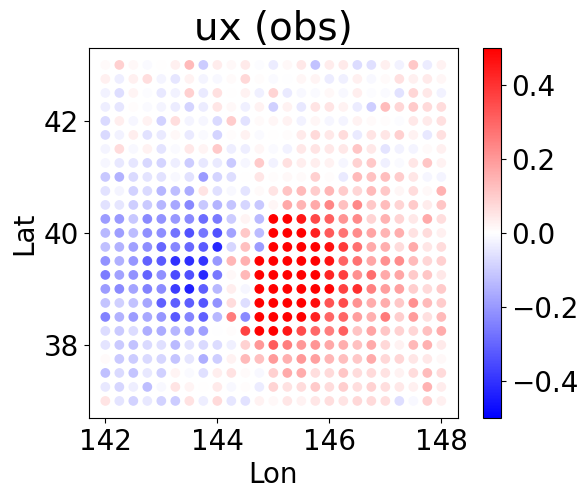

In [7]:
fig, ax = plt.subplots()
im = ax.scatter(Lon, Lat, c=ux_obs, cmap="bwr", vmin=-0.5, vmax=0.5)
ax.set_aspect("equal")
ax.set_xlabel("Lon")
ax.set_ylabel("Lat")
ax.set_title("ux (obs)", fontsize=28)
fig.colorbar(im)
fig.show()
# plt.tight_layout()
# fig.savefig("figs_loss/ux_obs.png")

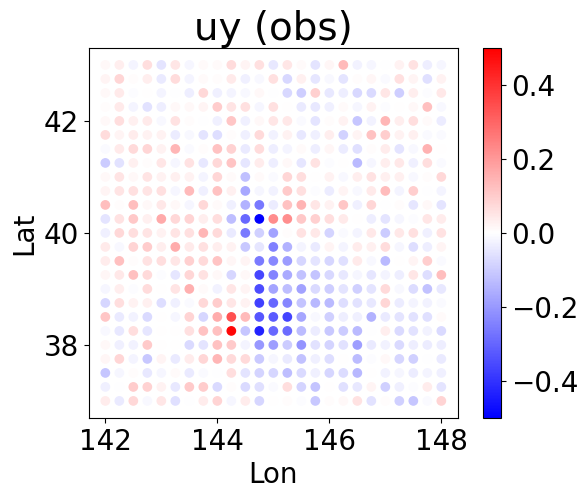

In [8]:
fig, ax = plt.subplots()
im = ax.scatter(Lon, Lat, c=uy_obs, cmap="bwr", vmin=-0.5, vmax=0.5)
ax.set_aspect("equal")
ax.set_xlabel("Lon")
ax.set_ylabel("Lat")
ax.set_title("uy (obs)", fontsize=28)
fig.colorbar(im)
fig.show()
# plt.tight_layout()
# fig.savefig("figs_loss/uy_obs.png")

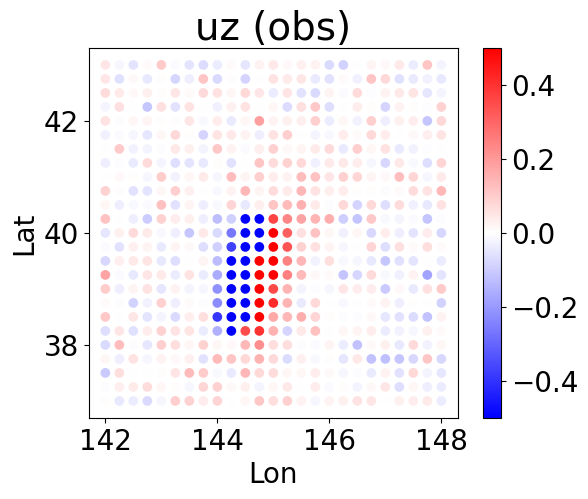

In [9]:
fig, ax = plt.subplots()
im = ax.scatter(Lon, Lat, c=uz_obs, cmap="bwr", vmin=-0.5, vmax=0.5)
ax.set_aspect("equal")
ax.set_xlabel("Lon")
ax.set_ylabel("Lat")
ax.set_title("uz (obs)", fontsize=28)
fig.colorbar(im)
fig.show()
# plt.tight_layout()
# fig.savefig("figs_loss/uz_obs.png")

# Gradient-based parameter estimation

For a successful optimization, it is desirable for the gradients with respect to each parameter to have the same order of magnitude.
Here, we perform a simple scaling: for each parameter `p`, we set a representative value `p0` and width `dp` in advance, and optimize the normalized parameter `q = (p-p0)/dp`.


[NOTE]

For some parameters (especially `x_fault` and `y_fault`), choise of initial values can greatly affect the results;
if they are chosen too far from the optimal values, the optimization will fail (the solution will diverge). 
In practical cases, it may be safer to keep those variables fixed at some values (= set `requires_grad=False`) and optimize only the other parameters.

The purpose here is only to demonstrate conceptually that optimization is possible using gradients obtained by automatic differentiation.
Actual applications would require more techniques.

In [10]:
def scale(p, p0, dp):
    q = {}
    for key in p:
        q[key] = (p[key] - p0[key]) / dp[key]
    return q

def unscale(q, p0, dp):
    p = {}
    for key in q:
        p[key] = p0[key] + dp[key] * q[key]
    return p

In [11]:
# parameters; target of optimization 
# choose appropriate initial values
params = {
    "x_fault": jnp.array(0.0),  
    "y_fault": jnp.array(10.0),
    "depth": jnp.array(1.0),
    "length": jnp.array(150.0),
    "width": jnp.array(60.0),
    "strike": jnp.array(200.0),
    "dip": jnp.array(45.0),
    "rake": jnp.array(300.0),
    "slip": jnp.array(10.0)
}

# save initial parameters; this is also used as the representative value 
p0 = {key: val for key, val in params.items()}

print("Initial parameters:")

for name in p0.keys():
    value = p0[name]
    print(name, value)


# choose appropriate width
dp = {
    "x_fault": jnp.array(dX), # scaled by domain size
    "y_fault": jnp.array(dY),
    "depth": jnp.array(10.0),
    "length": jnp.array(100.0),
    "width": jnp.array(100.0),
    "strike": jnp.array(180.0),
    "dip": jnp.array(90.0),
    "rake": jnp.array(180.0),
    "slip": jnp.array(5.0)
}

Initial parameters:
x_fault 0.0
y_fault 10.0
depth 1.0
length 150.0
width 60.0
strike 200.0
dip 45.0
rake 300.0
slip 10.0


In [12]:
ux, uy, uz = okada.compute(coords, params, compute_strain=False, is_degree=True, fault_origin="topleft")

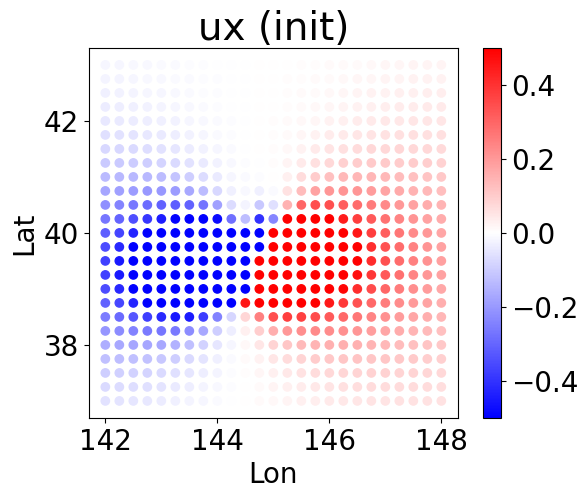

In [13]:
fig, ax = plt.subplots()
im = ax.scatter(Lon, Lat, c=ux, cmap="bwr", vmin=-0.5, vmax=0.5)
ax.set_aspect("equal")
ax.set_xlabel("Lon")
ax.set_ylabel("Lat")
ax.set_title("ux (init)", fontsize=28)
fig.colorbar(im)
fig.show()
# plt.tight_layout()
# fig.savefig("figs_loss/ux_init.png")

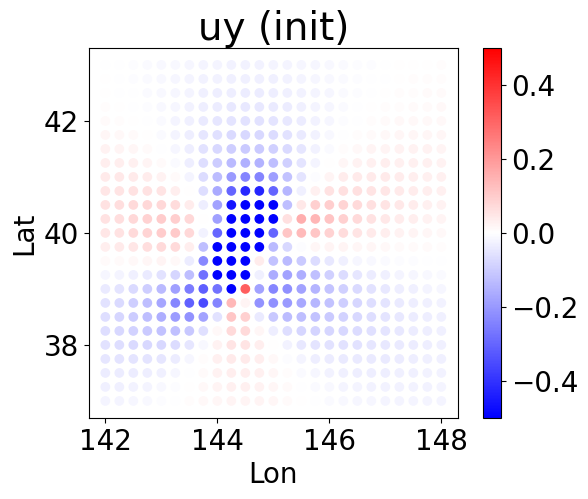

In [14]:
fig, ax = plt.subplots()
im = ax.scatter(Lon, Lat, c=uy, cmap="bwr", vmin=-0.5, vmax=0.5)
ax.set_aspect("equal")
ax.set_xlabel("Lon")
ax.set_ylabel("Lat")
ax.set_title("uy (init)", fontsize=28)
fig.colorbar(im)
fig.show()
# plt.tight_layout()
# fig.savefig("figs_loss/uy_init.png")

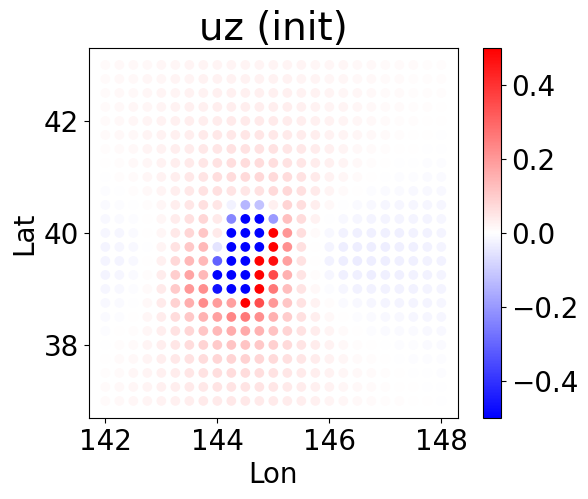

In [15]:
fig, ax = plt.subplots()
im = ax.scatter(Lon, Lat, c=uz, cmap="bwr", vmin=-0.5, vmax=0.5)
ax.set_aspect("equal")
ax.set_xlabel("Lon")
ax.set_ylabel("Lat")
ax.set_title("uz (init)", fontsize=28)
fig.colorbar(im)
fig.show()
# plt.tight_layout()
# fig.savefig("figs_loss/uz_init.png")

In [16]:
niter = 2000
ls = np.zeros(niter)

# optimizer handles normalized parameters
scaled_params = scale(params, p0, dp)
optimizer = optax.adam(learning_rate=1e-3)
opt_state = optimizer.init(scaled_params)


def loss(scaled_params):
    # unscale
    params = unscale(scaled_params, p0, dp)
    ux, uy, uz = okada.compute(coords, params, compute_strain=False, is_degree=True, fault_origin="topleft")
    res1 = ux - ux_obs
    res2 = uy - uy_obs
    res3 = uz - uz_obs
    l = 0.5 * jnp.sum(res1 * res1 + res2 * res2 + res3 * res3)
    return l

loss_and_grad = jax.value_and_grad(loss)



for iter in range(niter):
    l, grads = loss_and_grad(scaled_params)
    updates, opt_state = optimizer.update(grads, opt_state, scaled_params)
    scaled_params = optax.apply_updates(scaled_params, updates)

    ls[iter] = l

    print(f"Iteration {iter}: Loss = {l}")

Iteration 0: Loss = 96.21636962890625
Iteration 1: Loss = 95.85899353027344
Iteration 2: Loss = 94.37220764160156
Iteration 3: Loss = 92.60884094238281
Iteration 4: Loss = 92.2510986328125
Iteration 5: Loss = 91.47762298583984
Iteration 6: Loss = 90.12627410888672
Iteration 7: Loss = 89.00611114501953
Iteration 8: Loss = 88.42095184326172
Iteration 9: Loss = 87.69076538085938
Iteration 10: Loss = 86.61015319824219
Iteration 11: Loss = 85.57818603515625
Iteration 12: Loss = 84.85145568847656
Iteration 13: Loss = 84.18119812011719
Iteration 14: Loss = 83.33724975585938
Iteration 15: Loss = 82.39459228515625
Iteration 16: Loss = 81.5609130859375
Iteration 17: Loss = 80.88406372070312
Iteration 18: Loss = 80.18688201904297
Iteration 19: Loss = 79.3747329711914
Iteration 20: Loss = 78.55512237548828
Iteration 21: Loss = 77.8400650024414
Iteration 22: Loss = 77.18608856201172
Iteration 23: Loss = 76.4924087524414
Iteration 24: Loss = 75.74805450439453
Iteration 25: Loss = 75.02508544921875
I

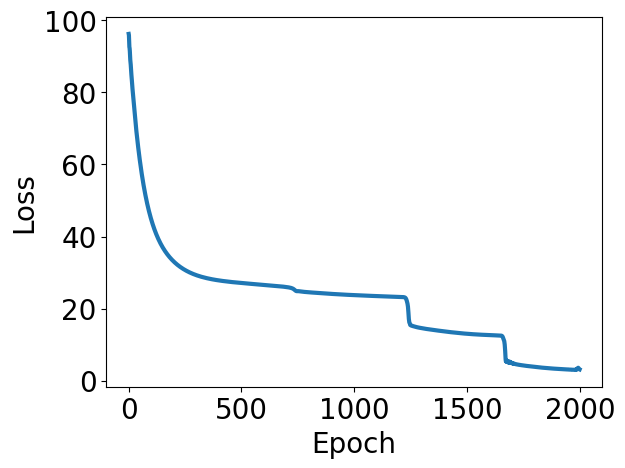

In [17]:
fig, ax = plt.subplots()
ax.plot(ls, lw=3)
ax.set_xlabel("Epoch")
ax.set_ylabel("Loss")
fig.show()
# plt.tight_layout()
# fig.savefig("figs_loss/loss.png")

In [18]:
# Calculate std via Laplace approximation
def paramsdict2matrix(dict):
    keys = list(dict.keys())
    return jnp.stack([
        jnp.stack([
            dict[row_key][col_key] for col_key in keys]) 
            for row_key in keys
    ])

hes = jax.hessian(loss)(scaled_params)
H = paramsdict2matrix(hes)
print(H)


# Sigma = jnp.linalg.inv(H)
Sigma = np.linalg.inv(H)
print(Sigma)

# Variance = jnp.diag(Sigma)
Variance = np.diag(Sigma)
print(Variance)


# Std = jnp.sqrt(Variance)
# Std = jnp.sqrt(jnp.maximum(Variance, 0.0))
Std = np.sqrt(np.maximum(Variance, 0.0))
print(Std)

Std2 = {}

for i, key in enumerate(params):
    Std2[key] = dp[key] * Std[i]

[[ 7.94395142e+01  1.49994522e+02 -1.43159461e+00  1.88867438e+00
  -2.48065605e+01  3.89400482e+00  2.23130703e+00  2.96103546e+02
  -4.47879639e+01]
 [ 1.49994431e+02  8.66524292e+02 -7.71385956e+00  1.09803686e+01
   1.01220131e+01 -1.49687515e+02  1.12918449e+02  1.25639282e+02
   2.51648064e+01]
 [-1.43025112e+00 -7.67936134e+00  4.18516083e+01  1.44157829e+01
   1.56018229e+01 -1.98005707e+02  3.08299751e+01  6.65857773e+01
  -1.50926437e+02]
 [ 1.88868117e+00  1.09797401e+01  1.44137554e+01  1.77591113e+03
   4.26478672e+00 -5.48393311e+02  6.78041792e+00 -5.76362610e+01
   1.87915985e+02]
 [-2.48065739e+01  1.01220779e+01  1.56027451e+01  4.26479626e+00
   1.00245712e+02  4.84188080e+02  1.23569115e+02 -4.20327942e+02
   1.22801628e+02]
 [ 3.89585900e+00 -1.49689316e+02 -1.94630341e+02 -5.48394043e+02
   4.84187622e+02  2.90084648e+04  9.79695251e+02 -1.87165605e+04
   4.26002295e+03]
 [ 2.23115087e+00  1.12918152e+02  3.08295841e+01  6.78039932e+00
   1.23569130e+02  9.7969512

In [19]:
params = unscale(scaled_params, p0, dp)


print("  param  |   true  |   init  |   est   |   std   | est-std | est+std |")

for name in params.keys():
    init = p0[name]
    true = params_true[name]
    est = params[name]
    std = Std2[name]
    print(f"{name:>8} | {true:7.3f} | {init:7.3f} | {est:7.3f} | {std:7.3f} | {est-std:7.3f} | {est+std:7.3f} |")


ux, uy, uz = okada.compute(coords, params, compute_strain=False, is_degree=True, fault_origin="topleft")

  param  |   true  |   init  |   est   |   std   | est-std | est+std |
   depth |   0.100 |   1.000 |   0.466 |   1.881 |  -1.414 |   2.347 |
     dip |  60.000 |  45.000 |  59.629 |   6.125 |  53.505 |  65.754 |
  length | 218.000 | 150.000 | 207.904 |   2.482 | 205.422 | 210.386 |
    rake | 270.000 | 300.000 | 270.048 |   4.292 | 265.756 | 274.340 |
    slip |   5.620 |  10.000 |   6.196 |   0.103 |   6.093 |   6.300 |
  strike | 189.000 | 200.000 | 188.465 |   3.231 | 185.233 | 191.696 |
   width |  46.000 |  60.000 |  41.924 |  14.622 |  27.302 |  56.546 |
 x_fault | -11.252 |   0.000 | -12.610 |  56.289 | -68.899 |  43.679 |
 y_fault |  24.703 |  10.000 |  22.831 |  16.792 |   6.039 |  39.624 |


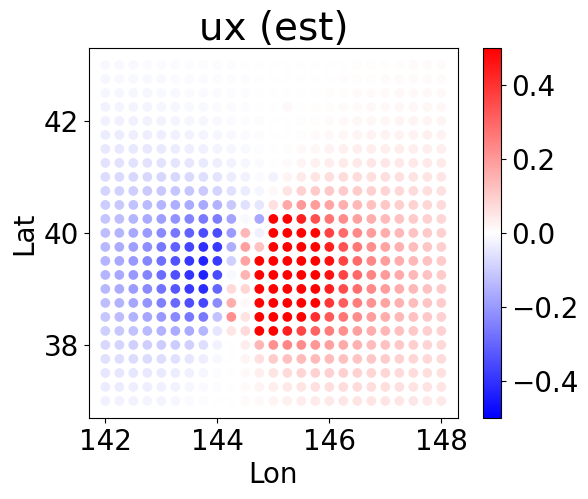

In [20]:
fig, ax = plt.subplots()
im = ax.scatter(Lon, Lat, c=ux, cmap="bwr", vmin=-0.5, vmax=0.5)
ax.set_aspect("equal")
ax.set_xlabel("Lon")
ax.set_ylabel("Lat")
ax.set_title("ux (est)", fontsize=28)
fig.colorbar(im)
fig.show()
# plt.tight_layout()
# fig.savefig("figs_loss/ux_est.png")

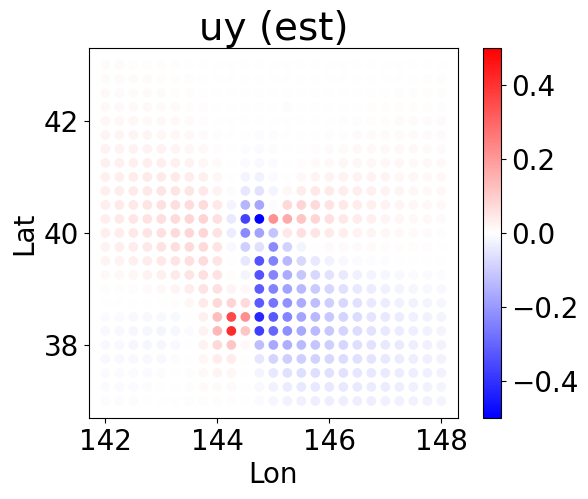

In [21]:
fig, ax = plt.subplots()
im = ax.scatter(Lon, Lat, c=uy, cmap="bwr", vmin=-0.5, vmax=0.5)
ax.set_aspect("equal")
ax.set_xlabel("Lon")
ax.set_ylabel("Lat")
ax.set_title("uy (est)", fontsize=28)
fig.colorbar(im)
fig.show()
# plt.tight_layout()
# fig.savefig("figs_loss/uy_est.png")

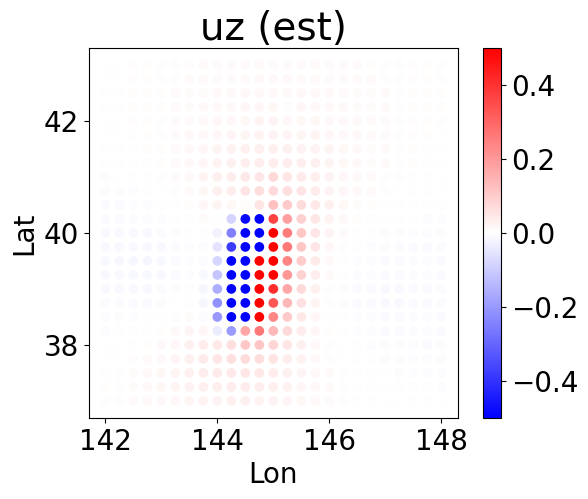

In [22]:
fig, ax = plt.subplots()
im = ax.scatter(Lon, Lat, c=uz, cmap="bwr", vmin=-0.5, vmax=0.5)
ax.set_aspect("equal")
ax.set_xlabel("Lon")
ax.set_ylabel("Lat")
ax.set_title("uz (est)", fontsize=28)
fig.colorbar(im)
fig.show()
# plt.tight_layout()
# fig.savefig("figs_loss/uz_est.png")